# Predictive Pricing Analytics using Machine Learning
##  Dynamic Pricing Engine

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
pricing_df = pd.read_csv("pricing_data_processed.csv")

In [3]:
X = pricing_df.drop(columns=["Sales", "Date"])
y = pricing_df["Sales"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
X_train_sample = X_train.sample(n=100000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

In [6]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

random_forest.fit(X_train_sample, y_train_sample)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_l

# Load Trained Machine Learning Model

Load the trained Random Forest model saved during the Machine Learning phase. This model will be used to generate sales predictions for the Dynamic Pricing Engine.

In [7]:
import joblib

joblib.dump(random_forest, "best_pricing_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Load Processed Dataset

Load the processed dataset created during the Feature Engineering phase. This dataset contains the features required by the trained machine learning model.

In [8]:
pricing_df = pd.read_csv("pricing_data_processed.csv")

In [9]:
pricing_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2,0,1270.0,9.0,2008.0,0,0.0,0.0,3
1,2,5,2015-07-31,6064,625,1,1,0,1,0,0,570.0,11.0,2007.0,1,13.0,2010.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,2,620.0,9.0,2009.0,0,0.0,0.0,3
4,5,5,2015-07-31,4822,559,1,1,0,1,0,0,29910.0,4.0,2015.0,0,0.0,0.0,3


# Dataset Information

Display the structure of the processed dataset to verify that all required features are available for prediction.

In [10]:
pricing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  int64  
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  int64  
 10  Assortment                 1017209 non-null  int64  
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  float64
 13  CompetitionOpenSinceYea

In [11]:
X = pricing_df.drop(columns=["Sales", "Date"])
y = pricing_df["Sales"]

In [12]:
prediction_data = pricing_df.drop(columns=["Sales", "Date"])

In [13]:
prediction_data.head()

,Store,DayOfWeek,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,555,1,1,0,1,2,0,1270.0,9.0,2008.0,0,0.0,0.0,3
1,2,5,625,1,1,0,1,0,0,570.0,11.0,2007.0,1,13.0,2010.0,1
2,3,5,821,1,1,0,1,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,1
3,4,5,1498,1,1,0,1,2,2,620.0,9.0,2009.0,0,0.0,0.0,3
4,5,5,559,1,1,0,1,0,0,29910.0,4.0,2015.0,0,0.0,0.0,3


# Generate Sales Predictions

Use the trained Random Forest model to predict sales based on the prepared input features.

In [14]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System
['.venv', '01_Data_Understanding.ipynb', '02_Exploratory_Data_Analysis.ipynb', '03_Feature_Engineering.ipynb', '04_Machine_Learning.ipynb', '05_Dynamic_Pricing_Engine.ipynb', 'best_pricing_model.pkl', 'dynamic_pricing_final.csv', 'pricing_data_processed.csv']


In [15]:
import joblib

model = joblib.load("best_pricing_model.pkl")

print(model)

RandomForestRegressor(max_depth=10, n_estimators=30, n_jobs=1, random_state=42)


In [16]:
prediction_data.head()

,Store,DayOfWeek,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,555,1,1,0,1,2,0,1270.0,9.0,2008.0,0,0.0,0.0,3
1,2,5,625,1,1,0,1,0,0,570.0,11.0,2007.0,1,13.0,2010.0,1
2,3,5,821,1,1,0,1,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,1
3,4,5,1498,1,1,0,1,2,2,620.0,9.0,2009.0,0,0.0,0.0,3
4,5,5,559,1,1,0,1,0,0,29910.0,4.0,2015.0,0,0.0,0.0,3


In [17]:
prediction_data.shape

(1017209, 16)

In [18]:
pricing_df["Predicted_Sales"] = model.predict(prediction_data)

# View Predicted Sales

Display the actual and predicted sales values to verify that the machine learning model generated predictions successfully.

In [19]:
pricing_df[
    ["Store", "Sales", "Predicted_Sales"]
].head(10)

,Store,Sales,Predicted_Sales
0,1,5263,4973.116995
1,2,6064,5425.755249
2,3,8314,8061.515002
3,4,13995,12290.098130
4,5,4822,5237.717770
5,6,5651,5167.522776
6,7,15344,13452.900317
7,8,8492,8016.553209
8,9,8565,6440.457301
9,10,7185,6538.150297


# Demand Classification

Classify predicted sales into demand categories (Low, Medium, High). These categories will be used to generate pricing recommendations.

In [20]:
def classify_demand(sales):
    if sales >= 8000:
        return "High"
    elif sales >= 4000:
        return "Medium"
    else:
        return "Low"

pricing_df["Demand_Level"] = pricing_df["Predicted_Sales"].apply(classify_demand)

In [21]:
pricing_df[
    ["Store", "Predicted_Sales", "Demand_Level"]
].head(10)

,Store,Predicted_Sales,Demand_Level
0,1,4973.116995,Medium
1,2,5425.755249,Medium
2,3,8061.515002,High
3,4,12290.098130,High
4,5,5237.717770,Medium
5,6,5167.522776,Medium
6,7,13452.900317,High
7,8,8016.553209,High
8,9,6440.457301,Medium
9,10,6538.150297,Medium


# Generate Pricing Recommendations

Generate pricing recommendations based on the predicted demand level. The pricing strategy aims to maximize revenue while responding to customer demand.

In [22]:
def pricing_recommendation(demand):

    if demand == "High":
        return "Increase Price by 5%"

    elif demand == "Medium":
        return "Maintain Current Price"

    else:
        return "Decrease Price by 5%"

pricing_df["Pricing_Recommendation"] = pricing_df["Demand_Level"].apply(
    pricing_recommendation
)

In [23]:
pricing_df[
    [
        "Store",
        "Predicted_Sales",
        "Demand_Level",
        "Pricing_Recommendation"
    ]
].head(10)

,Store,Predicted_Sales,Demand_Level,Pricing_Recommendation
0,1,4973.116995,Medium,Maintain Current Price
1,2,5425.755249,Medium,Maintain Current Price
2,3,8061.515002,High,Increase Price by 5%
3,4,12290.098130,High,Increase Price by 5%
4,5,5237.717770,Medium,Maintain Current Price
5,6,5167.522776,Medium,Maintain Current Price
6,7,13452.900317,High,Increase Price by 5%
7,8,8016.553209,High,Increase Price by 5%
8,9,6440.457301,Medium,Maintain Current Price
9,10,6538.150297,Medium,Maintain Current Price


# Revenue Impact Analysis

Estimate the impact of pricing recommendations on revenue using a simulated base price. Since the dataset does not contain product prices, a base price is assumed for demonstration purposes.

In [24]:
pricing_df["Base_Price"] = 100

In [25]:
def calculate_new_price(recommendation, base_price):

    if recommendation == "Increase Price by 5%":
        return base_price * 1.05

    elif recommendation == "Decrease Price by 5%":
        return base_price * 0.95

    else:
        return base_price

pricing_df["Recommended_Price"] = pricing_df.apply(
    lambda row: calculate_new_price(
        row["Pricing_Recommendation"],
        row["Base_Price"]
    ),
    axis=1
)

In [26]:
pricing_df["Expected_Revenue"] = (
    pricing_df["Predicted_Sales"] *
    pricing_df["Recommended_Price"]
)

# Pricing Recommendation Distribution

Visualize the distribution of pricing recommendations generated by the Dynamic Pricing Engine. This helps understand how many stores require price increases, decreases, or no price changes.

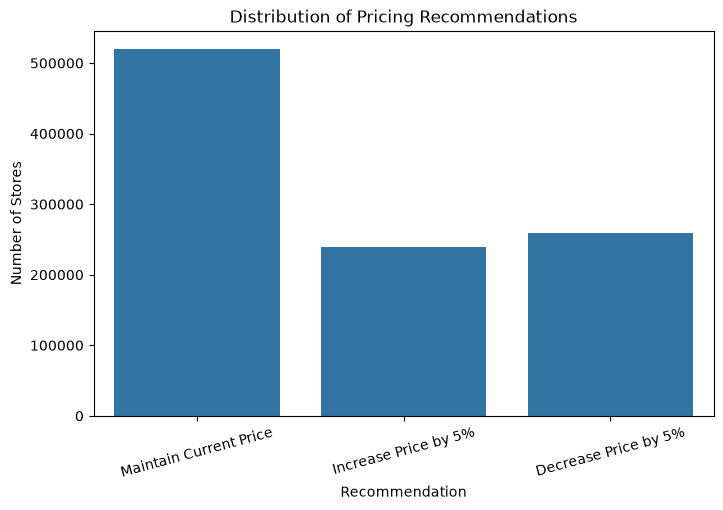

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=pricing_df,
    x="Pricing_Recommendation"
)

plt.title("Distribution of Pricing Recommendations")
plt.xlabel("Recommendation")
plt.ylabel("Number of Stores")

plt.xticks(rotation=15)

plt.show()

# Expected Revenue by Demand Level

Analyze the expected revenue generated by each demand category to understand which demand segments contribute the most to overall revenue.

In [28]:
revenue_summary = pricing_df.groupby("Demand_Level")["Expected_Revenue"].sum().reset_index()

revenue_summary

,Demand_Level,Expected_Revenue
0,High,2.626296e+11
1,Low,2.645720e+10
2,Medium,3.094791e+11


# Revenue by Demand Level

Visualize the total expected revenue generated by each demand category.

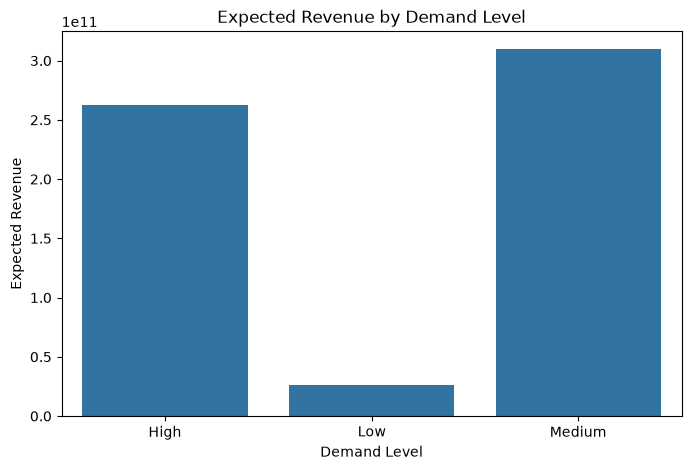

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=revenue_summary,
    x="Demand_Level",
    y="Expected_Revenue"
)

plt.title("Expected Revenue by Demand Level")
plt.xlabel("Demand Level")
plt.ylabel("Expected Revenue")

plt.show()

# Business KPI Summary

Calculate key business metrics generated by the Dynamic Pricing Engine to provide an executive-level overview of pricing recommendations and expected revenue.

In [30]:
total_revenue = pricing_df["Expected_Revenue"].sum()
average_predicted_sales = pricing_df["Predicted_Sales"].mean()
high_demand = (pricing_df["Demand_Level"] == "High").sum()
medium_demand = (pricing_df["Demand_Level"] == "Medium").sum()
low_demand = (pricing_df["Demand_Level"] == "Low").sum()

In [31]:
print(f"Total Expected Revenue : ₹{total_revenue:,.2f}")
print(f"Average Predicted Sales : {average_predicted_sales:.2f}")
print(f"High Demand Stores : {high_demand}")
print(f"Medium Demand Stores : {medium_demand}")
print(f"Low Demand Stores : {low_demand}")


Total Expected Revenue : ₹598,565,879,137.93
Average Predicted Sales : 5775.14
High Demand Stores : 238957
Medium Demand Stores : 519633
Low Demand Stores : 258619


# Business Insights

1. The machine learning model successfully predicted future sales for all stores using historical sales and store-related features.

2. Stores were classified into High, Medium, and Low demand categories based on predicted sales, making it easier to identify demand patterns.

3. The Dynamic Pricing Engine generated pricing recommendations for every store:
   - High Demand → Increase Price by 5%
   - Medium Demand → Maintain Current Price
   - Low Demand → Decrease Price by 5%

4. Most stores were classified under the "Maintain Current Price" category, indicating stable customer demand across a large portion of stores.

5. High-demand stores were identified as potential opportunities for revenue optimization through controlled price increases.

6. Low-demand stores were recommended for price reductions to encourage customer purchases and improve sales volume.

7. Revenue impact analysis demonstrated how pricing recommendations could influence expected revenue based on predicted sales.

8. The pricing recommendation distribution provides management with a quick overview of how many stores require pricing changes.

9. Business KPIs such as Total Expected Revenue, Average Predicted Sales, and Demand Distribution summarize the overall performance of the pricing strategy.

10. The Dynamic Pricing Engine transforms machine learning predictions into actionable business decisions, enabling data-driven pricing strategies instead of manual decision-making.

# Conclusion

The Dynamic Pricing Engine successfully combines machine learning predictions with rule-based business logic to generate pricing recommendations for each store. By classifying demand levels and estimating revenue impact, the system supports data-driven pricing decisions that can help optimize revenue and improve overall business performance.

In [32]:
pricing_df.to_csv(
    "dynamic_pricing_final.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [33]:
print(pricing_df.columns.tolist())

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Predicted_Sales', 'Demand_Level', 'Pricing_Recommendation', 'Base_Price', 'Recommended_Price', 'Expected_Revenue']


In [34]:
pricing_df.shape

(1017209, 24)

In [35]:
pricing_df.to_csv(
    "dynamic_pricing_final.csv",
    index=False
)

print("Final 24-column dataset saved successfully!")

Final 24-column dataset saved successfully!
